# Train, predict, score, and evaluate a Sequence CNN on PLAsTiCC

This notebook uses `dlip_plasticc` package on top of `avocado`.


In [ ]:
# Notebook parameters

CONFIG_DEFAULT_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/default.toml'
CONFIG_LOCAL_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/local.toml'

# Training
TRAIN_DATASET_NAME = 'plasticc_augment'
CLASSIFIER_NAME = 'my_sequence_cnn'
SEQ_LEN = 350
NUM_EPOCHS = 100
BATCH_SIZE = 64
LR = 1e-4
DROPOUT = 0.2

# Prediction
TEST_DATASET_NAME = 'plasticc_test'
TOTAL_CHUNKS = 500

# Change this list to the chunks you actually want to run.
# For a quick smoke test, use something like [0, 1, 2].
CHUNKS = range(21)

# Output location for per-chunk and combined predictions.
OUT_DIR = 'notebook_outputs/sequence_cnn_predictions'

# Confusion matrix display options
CONFUSION_NORMALIZE = 'true'  # one of: None, 'true', 'pred', 'all'
FIGSIZE_HISTORY = (8, 5)
FIGSIZE_CONFUSION = (10, 8)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import avocado

from dlip_plasticc.config import load_config, apply_avocado_settings
from dlip_plasticc.features import PlasticcSequenceFeaturizer
from dlip_plasticc.models import SequenceCNNClassifier
from dlip_plasticc.pipelines.predict import predict_partial_from_dataset
from dlip_plasticc.pipelines.score import score_flat, align_truth_and_predictions

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [4]:
# Load config and push paths into avocado
cfg = load_config(CONFIG_DEFAULT_PATH, CONFIG_LOCAL_PATH)
apply_avocado_settings(cfg)

print('Using avocado paths:')
print('  data_directory       =', avocado.settings['data_directory'])
print('  features_directory   =', avocado.settings['features_directory'])
print('  predictions_directory=', avocado.settings['predictions_directory'])
print('  classifier_directory =', avocado.settings['classifier_directory'])


Using avocado paths:
  data_directory       = /scratch/s4339150/plasticc/data
  features_directory   = /scratch/s4339150/plasticc/features
  predictions_directory= /scratch/s4339150/plasticc/predictions
  classifier_directory = /scratch/s4339150/plasticc/classifiers


## 1. Train the Sequence CNN

This uses online sequence featurization from raw observations in the training dataset.

In [5]:
featurizer = PlasticcSequenceFeaturizer(seq_len=SEQ_LEN)

classifier = SequenceCNNClassifier(
    name=CLASSIFIER_NAME,
    featurizer=featurizer,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    dropout=DROPOUT,
)

print(f"Loading training dataset '{TRAIN_DATASET_NAME}'...")
train_dataset = avocado.load(TRAIN_DATASET_NAME)

print('Extracting sequence raw features...')
train_dataset.extract_raw_features(featurizer)

print(f"Training classifier '{CLASSIFIER_NAME}'...")
classifier.train(
    train_dataset,
    num_folds=5,
    random_state=42,
    val_fold=0,
    weight_decay=1e-2,
    lr_scheduler_factor=0.5,
    lr_scheduler_patience=2,
    min_lr=1e-6,
    early_stopping_patience=20,
    show_progress=True,
)

Loading training dataset 'plasticc_augment'...
Extracting sequence raw features...


Object: 100%|██████████| 66532/66532 [00:50<00:00, 1321.93it/s]


Training classifier 'my_sequence_cnn'...


Epochs:   5%|▌         | 1/20 [00:07<02:13,  7.02s/it]

Epoch 1 train_loss: 1.92449 val_loss: 1.51263 val_acc: 0.50512 val_macro_f1: 0.25106 val_bal_acc: 0.28064 lr: 1.000000e-04


...

Epochs:  95%|█████████▌| 19/20 [02:05<00:06,  6.56s/it]

Epoch 19 train_loss: 1.13383 val_loss: 0.90810 val_acc: 0.69826 val_macro_f1: 0.53909 val_bal_acc: 0.53739 lr: 1.000000e-04


Epochs: 100%|██████████| 20/20 [02:11<00:00,  6.59s/it]

Epoch 20 train_loss: 1.12624 val_loss: 0.88862 val_acc: 0.70469 val_macro_f1: 0.54471 val_bal_acc: 0.53610 lr: 1.000000e-04
Best validation loss: 0.88862


_SequenceCNNNet(
  (cont_norm): LayerNorm((6,), eps=1e-05, elementwise_affine=True)
  (cont_proj): Linear(in_features=6, out_features=56, bias=True)
  (band_emb): Embedding(6, 8)
  (input_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (input_dropout): Dropout(p=0.2, inplace=False)
  (blocks): ModuleList(
    (0): _ResidualTemporalBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act1): GELU(approximate='none')
      (drop1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act2): GELU(approximate='none')
      (drop2): Dropout(p=0.2, inplace=False)
      (skip): Identity()
    )
    (1): _ResidualTemporalBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      

In [6]:
# Save the trained classifier
classifier.write(overwrite=True)
print('Classifier written to:', classifier.path)


Classifier written to: /scratch/s4339150/plasticc/classifiers/classifier_my_sequence_cnn.pkl


## 2. Plot training history

In [7]:
history = classifier.history.copy()
history.tail()


,epoch,train_loss,val_loss,val_acc,val_macro_f1,val_balanced_acc,lr
15,16,1.164482,0.933149,0.688683,0.525896,0.537393,0.0001
16,17,1.154189,0.935137,0.684494,0.525523,0.538263,0.0001
17,18,1.141869,0.910537,0.699828,0.540360,0.534369,0.0001
18,19,1.133829,0.908095,0.698257,0.539088,0.537385,0.0001
19,20,1.126238,0.888625,0.704690,0.544710,0.536098,0.0001


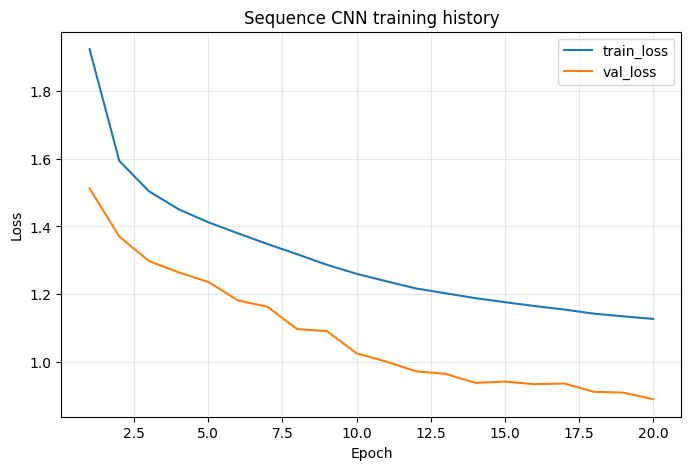

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history["epoch"], history["train_loss"], label="train_loss")
ax.plot(history["epoch"], history["val_loss"], label="val_loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Sequence CNN training history")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 3. Predict on test chunks

In [ ]:
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

combined_predictions, processed_chunks = predict_partial_from_dataset(
    classifier=classifier,
    featurizer=featurizer,
    dataset_name=TEST_DATASET_NAME,
    total_chunks=TOTAL_CHUNKS,
    chunks=CHUNKS,
    out_dir=OUT_DIR,
    metadata_only=False,
    show_progress=True,
)

print('Processed chunks:', processed_chunks)
print('Combined prediction shape:', combined_predictions.shape)
combined_predictions.head()


Chunks:  33%|███▎      | 7/21 [01:02<01:55,  8.26s/it]

## 4. Score predictions with avocado flat-weighted logloss

This scores only on the overlapping labeled objects available in the metadata.

In [ ]:
flat_score, n_scored = score_flat(TEST_DATASET_NAME, combined_predictions)
print(f'Flat-weighted logloss: {flat_score:.5f}')
print(f'Objects scored:        {n_scored:,}')


Flat-weighted logloss: 1.29800
Objects scored:        146,085


## 5. Confusion matrix

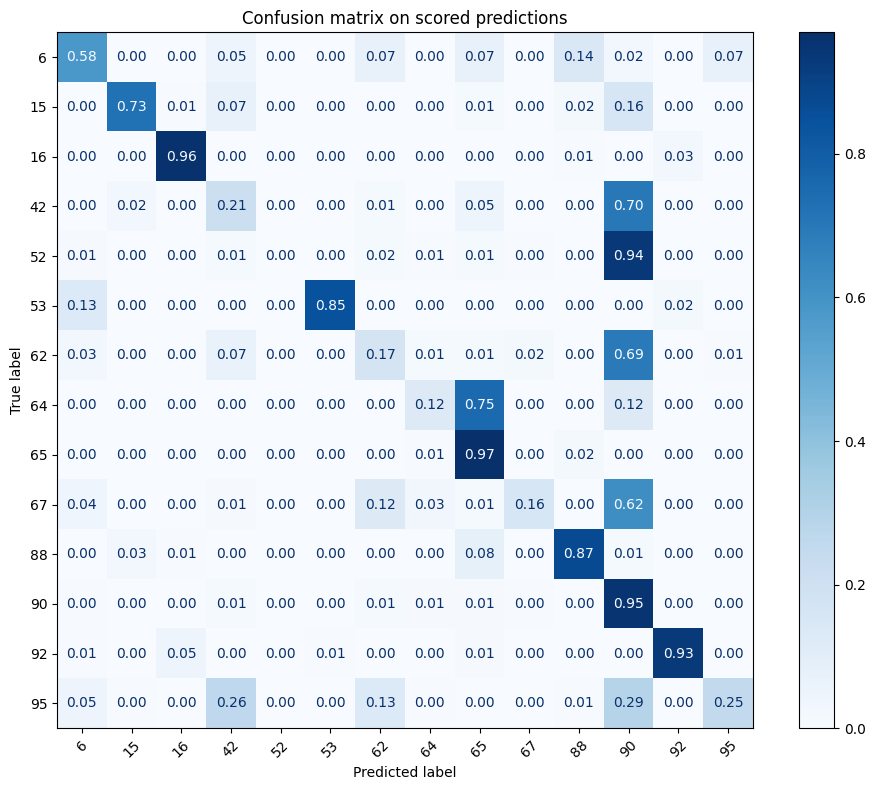

In [ ]:
y_true, pred_aligned = align_truth_and_predictions(
    TEST_DATASET_NAME,
    combined_predictions,
    known_classes_only=True,
    normalize=True,
)

y_pred = pred_aligned.idxmax(axis=1)
labels = sorted(np.unique(np.concatenate([y_true.values, y_pred.values])))

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=CONFUSION_NORMALIZE)

fig, ax = plt.subplots(figsize=FIGSIZE_CONFUSION)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues', values_format='.2f')
ax.set_title('Confusion matrix on scored predictions')
plt.tight_layout()
plt.show()


In [ ]:
print(classification_report(y_true, y_pred, digits=4))
